测试extensive transfomer版本的笔记本

In [1]:
import sys
import inspect
from pathlib import Path

repo_path = Path(r"D:\MEGNET_GITHUB\matgl")
src_path = repo_path / "src"

# 确保优先导入当前项目中的源码，而不是 site-packages 里的官方 MatGL
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import torch
import matgl

from matgl.models._m3gnet import M3GNet
from matgl.layers._readout_torch import TransformerAtomicReadOut

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("MatGL path:", Path(inspect.getfile(matgl)).resolve())
print("M3GNet path:", Path(inspect.getfile(M3GNet)).resolve())
print(
    "TransformerAtomicReadOut path:",
    Path(inspect.getfile(TransformerAtomicReadOut)).resolve(),
)

W0720 13:09:03.842000 33700 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Python: d:\anaconda\python.exe
PyTorch: 2.11.0+cu128
CUDA version: 12.8
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
MatGL path: D:\MEGNET_GITHUB\matgl\src\matgl\__init__.py
M3GNet path: D:\MEGNET_GITHUB\matgl\src\matgl\models\_m3gnet.py
TransformerAtomicReadOut path: D:\MEGNET_GITHUB\matgl\src\matgl\layers\_readout_torch.py


In [2]:
from pymatgen.core import Lattice, Structure

structure = Structure(
    Lattice.cubic(5.43),
    ["Si", "Si"],
    [[0, 0, 0], [0.25, 0.25, 0.25]],
)

model = M3GNet(
    element_types=("Si",),
    is_intensive=False,               # 走 extensive 原子能量求和路线
    readout_type="transformer",
    transformer_nhead=4,
    transformer_num_layers=1,
    transformer_dim_ff=128,
    transformer_dropout=0.0,
)

model.eval()

with torch.no_grad():
    energy = model.predict_structure(structure)

atomic_energies = model.feature_dict["readout"].view(-1)
final_energy = model.feature_dict["final"].view(-1)

print("is_intensive:", model.is_intensive)
print("readout_type:", model.readout_type)
print("final layer:", type(model.final_layer).__name__)

print("number of atoms:", len(structure))
print("atomic energies shape:", atomic_energies.shape)
print("atomic energies:", atomic_energies)

print("sum of atomic energies:", atomic_energies.sum())
print("model final energy:", final_energy)
print("predict_structure output:", energy)

print(
    "sum check:",
    torch.allclose(
        atomic_energies.sum(),
        final_energy[0],
        atol=1e-6,
    ),
)

is_intensive: False
readout_type: transformer
final layer: TransformerAtomicReadOut
number of atoms: 2
atomic energies shape: torch.Size([2])
atomic energies: tensor([0.0191, 0.0191])
sum of atomic energies: tensor(0.0381)
model final energy: tensor([0.0381])
predict_structure output: tensor(0.0381)
sum check: True


In [3]:
import json
import numpy as np

from functools import partial
from ase.stress import voigt_6_to_full_3x3_stress

from matgl.config import DEFAULT_ELEMENTS
from matgl.graph.data import (
    MGLDataLoader,
    collate_fn_pes,
    split_dataset,
)
from matgl.utils.training import MGLDatasetLoader

# 复用之前从完整MatPES中等概率随机抽出的1000条
random_1k_path = (
    repo_path
    / "MatPES-PBE-2025.2-random-1000-seed-2029.json"
)

assert random_1k_path.exists(), random_1k_path

# 查看随机子集的结构复杂度
with random_1k_path.open("r", encoding="utf-8") as f:
    metadata_random_1k = json.load(f)

atom_counts = np.array(
    [item["nsites"] for item in metadata_random_1k]
)

print("number of structures:", len(metadata_random_1k))
print(
    "atom count min/mean/max:",
    atom_counts.min(),
    atom_counts.mean(),
    atom_counts.max(),
)
print(
    "unique formulas:",
    len({item["formula_pretty"] for item in metadata_random_1k}),
)

# JSON中的结构和标签转换成PyG图数据集
dataset_random_1k = MGLDatasetLoader.from_json(
    random_1k_path,
    cutoff=5.0,
    element_types=DEFAULT_ELEMENTS,
    save_cache=False,
    root="tmp_extensive_transformer_random_1000",
    stress_unit="kbar",
)

# MatPES应力是Voigt六分量，转换成MatGL训练所需的3×3矩阵
fixed_stresses = []

for stress in dataset_random_1k.labels["stresses"]:
    stress = np.asarray(stress, dtype=float)

    if stress.shape == (6,):
        stress = voigt_6_to_full_3x3_stress(stress)

    fixed_stresses.append(stress.tolist())

dataset_random_1k.labels["stresses"] = fixed_stresses

# 固定划分，保持与旧实验一致
train_random_1k, val_random_1k, test_random_1k = split_dataset(
    dataset_random_1k,
    frac_list=[0.8, 0.1, 0.1],
    shuffle=True,
    random_state=42,
)

collate_random_1k = partial(
    collate_fn_pes,
    include_stress=True,
)

train_loader, val_loader, test_loader = MGLDataLoader(
    train_data=train_random_1k,
    val_data=val_random_1k,
    test_data=test_random_1k,
    collate_fn=collate_random_1k,
    batch_size=4,
    num_workers=0,
    pin_memory=True,
)

print(
    "split:",
    len(train_random_1k),
    len(val_random_1k),
    len(test_random_1k),
)
print(
    "batches:",
    len(train_loader),
    len(val_loader),
    len(test_loader),
)
print(
    "stress shape:",
    np.asarray(dataset_random_1k.labels["stresses"][0]).shape,
)

number of structures: 1000
atom count min/mean/max: 1 9.121 168
unique formulas: 960


Processing...
100%|██████████| 1000/1000 [00:00<00:00, 3949.08it/s]

split: 800 100 100
batches: 200 25 25
stress shape: (3, 3)



Done!


In [ ]:
import time
import pandas as pd
import lightning as L

from contextlib import nullcontext
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger
from torch.nn.attention import SDPBackend, sdpa_kernel

from matgl.utils.training import (
    PotentialLightningModule,
    xavier_init,
)

EPOCHS = 5


def run_experiment(name: str, use_transformer: bool):
    # 两个实验从相同随机种子开始
    L.seed_everything(42, workers=True)

    if use_transformer:
        model = M3GNet(
            element_types=DEFAULT_ELEMENTS,
            is_intensive=False,
            readout_type="transformer",
            transformer_nhead=4,
            transformer_num_layers=1,
            transformer_dim_ff=128,
            transformer_dropout=0.0,
        )
    else:
        # 原始M3GNet extensive：
        # GatedMLP逐原子能量 -> sum
        model = M3GNet(
            element_types=DEFAULT_ELEMENTS,
            is_intensive=False,
        )

    xavier_init(model)

    lit_model = PotentialLightningModule(
        model=model,
        energy_weight=1.0,
        force_weight=1.0,
        stress_weight=0.1,
        loss="huber_loss",
        lr=1e-3,
    )

    logger = CSVLogger(
        save_dir="logs",
        name=f"{name}_random1000_atomic_sum",
    )

    checkpoint = ModelCheckpoint(
        monitor="val_Total_Loss",
        mode="min",
        save_top_k=1,
        filename="best-{epoch:02d}-{step}",
    )

    trainer = L.Trainer(
        max_epochs=EPOCHS,
        accelerator="gpu",
        devices=1,
        precision="32-true",
        inference_mode=False,
        logger=logger,
        callbacks=[checkpoint],
        num_sanity_val_steps=0,
        log_every_n_steps=20,
        gradient_clip_val=2.0,
    )

    print("\nModel:", name)
    print("is_intensive:", model.is_intensive)
    print("readout_type:", model.readout_type)
    print("final layer:", type(model.final_layer).__name__)
    print(
        "trainable parameters:",
        sum(p.numel() for p in model.parameters() if p.requires_grad),
    )

    start = time.perf_counter()

    # Transformer训练力时需要对能量梯度继续反向传播，
    # 使用MATH SDPA以支持二阶导数
    attention_context = (
        sdpa_kernel(SDPBackend.MATH)
        if use_transformer
        else nullcontext()
    )

    with attention_context:
        trainer.fit(
            model=lit_model,
            train_dataloaders=train_loader,
            val_dataloaders=val_loader,
        )

        test_result = trainer.test(
            model=lit_model,
            dataloaders=test_loader,
            ckpt_path=checkpoint.best_model_path,
        )[0]

    test_result["model"] = name
    test_result["minutes"] = (
        time.perf_counter() - start
    ) / 60
    test_result["parameters"] = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )
    test_result["best_checkpoint"] = checkpoint.best_model_path

    return test_result, model, trainer


transformer_result, transformer_model, transformer_trainer = (
    run_experiment(
        name="Transformer-AtomicSum-M3GNet",
        use_transformer=True,
    )
)

baseline_result, baseline_model, baseline_trainer = (
    run_experiment(
        name="Original-M3GNet",
        use_transformer=False,
    )
)

comparison = pd.DataFrame(
    [transformer_result, baseline_result]
).set_index("model")

display(
    comparison[
        [
            "test_Energy_MAE",
            "test_Force_MAE",
            "test_Stress_MAE",
            "test_Total_Loss",
            "minutes",
            "parameters",
        ]
    ]
)

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 4060 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision



Model: Transformer-AtomicSum-M3GNet
is_intensive: False
readout_type: transformer
final layer: TransformerAtomicReadOut
trainable parameters: 321629


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ mae   │ MeanAbsoluteError │      0 │ train │     0 │
│ 1 │ rmse  │ MeanSquaredError  │      0 │ train │     0 │
│ 2 │ model │ Potential         │  321 K │ train │     0 │
└───┴───────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 321 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 321 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 187                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

`Trainer.fit` stopped: `max_epochs=5` reached.


Restoring states from the checkpoint path at logs\Original-M3GNet_random1000_atomic_sum\version_0\checkpoints\best-epoch=04-step=1000.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at logs\Original-M3GNet_random1000_atomic_sum\version_0\checkpoints\best-epoch=04-step=1000.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      test_Charge_MAE      │            0.0            │
│     test_Charge_RMSE      │            0.0            │
│      test_Energy_MAE      │     0.719635546207428     │
│     test_Energy_RMSE      │    0.8128623962402344     │
│      test_Force_MAE       │    0.39368483424186707    │
│      test_Force_RMSE      │    0.6549623012542725     │
│      test_Magmom_MAE      │            0.0            │
│     test_Magmom_RMSE      │            0.0            │
│      test_Stress_MAE      │    3.3029227256774902     │
│     test_Stress_RMSE      │     4.983431339263916     │
│      test_Total_Loss      │    0.8112702965736389     │
└───────────────────────────┴───────────────────────────┘

,test_Energy_MAE,test_Force_MAE,test_Stress_MAE,test_Total_Loss,minutes,parameters
model,,,,,,
Transformer-AtomicSum-M3GNet,0.579563,0.388557,2.919115,0.68426,3.250784,321629
Original-M3GNet,0.719636,0.393685,3.302923,0.81127,2.997959,288157


接下来在更大数据集上测试

从完整 MatPES-PBE-2025.2 数据文件中等概率随机抽5000条

In [4]:
import json
import random
import ijson

from pathlib import Path
from huggingface_hub import hf_hub_download

TARGET_N = 5_000
SAMPLE_SEED = 2030

# 获取完整MatPES数据文件路径。
# 文件已经下载过时，会直接使用本地Hugging Face缓存。
raw_path = Path(
    hf_hub_download(
        repo_id="materialyze/matpes",
        filename="MatPES-PBE-2025.2.json",
        repo_type="dataset",
    )
)

random_5k_path = (
    repo_path
    / f"MatPES-PBE-2025.2-random-{TARGET_N}"
      f"-seed-{SAMPLE_SEED}.json"
)

tmp_path = random_5k_path.with_suffix(".json.tmp")

if not random_5k_path.exists():
    rng = random.Random(SAMPLE_SEED)
    reservoir = []
    seen = 0

    # Reservoir sampling：
    # 扫描完整数据后，每一条数据被选中的概率相同。
    with raw_path.open("rb") as f:
        for seen, item in enumerate(
            ijson.items(f, "item", use_float=True),
            start=1,
        ):
            item_json = json.dumps(
                item,
                ensure_ascii=False,
                separators=(",", ":"),
            )

            if seen <= TARGET_N:
                reservoir.append(item_json)
            else:
                j = rng.randrange(seen)

                if j < TARGET_N:
                    reservoir[j] = item_json

            if seen % 100_000 == 0:
                print(f"已经扫描：{seen:,} 条")

    if seen < TARGET_N:
        raise ValueError(
            f"完整数据只有{seen}条，少于要求的{TARGET_N}条"
        )

    rng.shuffle(reservoir)

    with tmp_path.open("w", encoding="utf-8") as out:
        out.write("[\n")
        out.write(",\n".join(reservoir))
        out.write("\n]\n")

    tmp_path.replace(random_5k_path)

print("full dataset:", raw_path)
print("random subset:", random_5k_path)
print("file size MB:", random_5k_path.stat().st_size / 1024**2)

with random_5k_path.open("r", encoding="utf-8") as f:
    metadata_5k = json.load(f)

atom_counts_5k = np.array(
    [item["nsites"] for item in metadata_5k]
)

print("structures:", len(metadata_5k))
print(
    "atoms min/mean/max:",
    atom_counts_5k.min(),
    atom_counts_5k.mean(),
    atom_counts_5k.max(),
)
print(
    "unique formulas:",
    len({item["formula_pretty"] for item in metadata_5k}),
)

已经扫描：100,000 条
已经扫描：200,000 条
已经扫描：300,000 条
已经扫描：400,000 条
full dataset: C:\Users\ASUS\.cache\huggingface\hub\datasets--materialyze--matpes\snapshots\47d2cc020cf913b5a48a3480136a128dddc0a92c\MatPES-PBE-2025.2.json
random subset: D:\MEGNET_GITHUB\matgl\MatPES-PBE-2025.2-random-5000-seed-2030.json
file size MB: 23.89630699157715
structures: 5000
atoms min/mean/max: 1 8.9514 168
unique formulas: 4188


接下来：5000条JSON

→ 转成PyG晶体图

→ 按original_mp_id分组

→ 80%训练、10%验证、10%测试

→ 创建DataLoader

In [5]:
import numpy as np

from functools import partial
from torch.utils.data import Subset
from sklearn.model_selection import GroupShuffleSplit
from ase.stress import voigt_6_to_full_3x3_stress

from matgl.config import DEFAULT_ELEMENTS
from matgl.graph.data import MGLDataLoader, collate_fn_pes
from matgl.utils.training import MGLDatasetLoader

dataset_5k = MGLDatasetLoader.from_json(
    random_5k_path,
    cutoff=5.0,
    element_types=DEFAULT_ELEMENTS,
    save_cache=True,
    root="tmp_extensive_transformer_random_5000_seed2030",
    stress_unit="kbar",
)

# 把应力从6分量变成3×3
fixed_stresses_5k = []

for stress in dataset_5k.labels["stresses"]:
    stress = np.asarray(stress, dtype=float)

    if stress.shape == (6,):
        stress = voigt_6_to_full_3x3_stress(stress)

    fixed_stresses_5k.append(stress.tolist())

dataset_5k.labels["stresses"] = fixed_stresses_5k

indices_5k = np.arange(len(dataset_5k))
groups_5k = np.array([
    item["provenance"]["original_mp_id"]
    for item in metadata_5k
])

# 80%训练，20%临时集
split_train = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42,
)

train_idx_5k, temp_idx_5k = next(
    split_train.split(indices_5k, groups=groups_5k)
)

# 临时集平分为验证集和测试集
split_val_test = GroupShuffleSplit(
    n_splits=1,
    test_size=0.5,
    random_state=43,
)

val_relative, test_relative = next(
    split_val_test.split(
        temp_idx_5k,
        groups=groups_5k[temp_idx_5k],
    )
)

val_idx_5k = temp_idx_5k[val_relative]
test_idx_5k = temp_idx_5k[test_relative]

train_data_5k = Subset(dataset_5k, train_idx_5k.tolist())
val_data_5k = Subset(dataset_5k, val_idx_5k.tolist())
test_data_5k = Subset(dataset_5k, test_idx_5k.tolist())

train_groups = set(groups_5k[train_idx_5k])
val_groups = set(groups_5k[val_idx_5k])
test_groups = set(groups_5k[test_idx_5k])

assert train_groups.isdisjoint(val_groups)
assert train_groups.isdisjoint(test_groups)
assert val_groups.isdisjoint(test_groups)

collate_5k = partial(collate_fn_pes, include_stress=True)

train_loader_5k, val_loader_5k, test_loader_5k = MGLDataLoader(
    train_data=train_data_5k,
    val_data=val_data_5k,
    test_data=test_data_5k,
    collate_fn=collate_5k,
    batch_size=4,
    num_workers=0,
    pin_memory=True,
)

print("dataset size:", len(dataset_5k))
print(
    "split:",
    len(train_data_5k),
    len(val_data_5k),
    len(test_data_5k),
)
print(
    "batches:",
    len(train_loader_5k),
    len(val_loader_5k),
    len(test_loader_5k),
)
print(
    "group overlap:",
    len(train_groups & val_groups),
    len(train_groups & test_groups),
    len(val_groups & test_groups),
)
print(
    "stress shape:",
    np.asarray(dataset_5k.labels["stresses"][0]).shape,
)

Processing...
100%|██████████| 5000/5000 [00:01<00:00, 3619.22it/s]
Done!


dataset size: 5000
split: 4017 497 486
batches: 1005 125 122
group overlap: 0 0 0
stress shape: (3, 3)


现在先定义：

改良版 Transformer 模型。

实时损失曲线 callback。

最佳 checkpoint。

最多30轮。

连续5轮无显著改善自动停止。

In [6]:
import matplotlib.pyplot as plt
import lightning as L

from lightning.pytorch import Callback
from lightning.pytorch.callbacks import (
    EarlyStopping,
    LearningRateMonitor,
    ModelCheckpoint,
)
from lightning.pytorch.loggers import CSVLogger
from IPython.display import clear_output, display

from matgl.utils.training import (
    PotentialLightningModule,
    xavier_init,
)


class LiveMetricsPlot(Callback):
    """每个验证epoch结束后刷新训练曲线。"""

    def __init__(self):
        super().__init__()

        self.epochs = []
        self.train_loss = []
        self.val_loss = []
        self.val_energy_mae = []
        self.val_force_mae = []
        self.val_stress_mae = []

    @staticmethod
    def metric_value(metrics, name):
        value = metrics.get(name)

        if value is None:
            return float("nan")

        return float(value.detach().cpu())

    def on_validation_epoch_end(self, trainer, pl_module):
        if trainer.sanity_checking:
            return

        metrics = trainer.callback_metrics

        self.epochs.append(trainer.current_epoch + 1)
        self.train_loss.append(
            self.metric_value(metrics, "train_Total_Loss")
        )
        self.val_loss.append(
            self.metric_value(metrics, "val_Total_Loss")
        )
        self.val_energy_mae.append(
            self.metric_value(metrics, "val_Energy_MAE")
        )
        self.val_force_mae.append(
            self.metric_value(metrics, "val_Force_MAE")
        )
        self.val_stress_mae.append(
            self.metric_value(metrics, "val_Stress_MAE")
        )

        clear_output(wait=True)

        fig, axes = plt.subplots(
            2,
            2,
            figsize=(11, 7),
        )

        axes[0, 0].plot(
            self.epochs,
            self.train_loss,
            marker="o",
            label="Train",
        )
        axes[0, 0].plot(
            self.epochs,
            self.val_loss,
            marker="o",
            label="Validation",
        )
        axes[0, 0].set_title("Total Loss")
        axes[0, 0].legend()

        axes[0, 1].plot(
            self.epochs,
            self.val_energy_mae,
            marker="o",
        )
        axes[0, 1].set_title("Validation Energy MAE")

        axes[1, 0].plot(
            self.epochs,
            self.val_force_mae,
            marker="o",
        )
        axes[1, 0].set_title("Validation Force MAE")

        axes[1, 1].plot(
            self.epochs,
            self.val_stress_mae,
            marker="o",
        )
        axes[1, 1].set_title("Validation Stress MAE")

        for ax in axes.flat:
            ax.set_xlabel("Epoch")
            ax.grid(alpha=0.3)

        fig.suptitle(
            "Transformer Atomic-Sum M3GNet: Live Training"
        )
        fig.tight_layout()

        display(fig)
        plt.close(fig)

        print(
            f"Epoch {trainer.current_epoch + 1}: "
            f"train_loss={self.train_loss[-1]:.4f}, "
            f"val_loss={self.val_loss[-1]:.4f}"
        )


# 固定初始化，方便之后与原始M3GNet公平比较
L.seed_everything(42, workers=True)
torch.set_float32_matmul_precision("high")

transformer_5k_model = M3GNet(
    element_types=DEFAULT_ELEMENTS,
    is_intensive=False,
    readout_type="transformer",
    transformer_nhead=4,
    transformer_num_layers=1,
    transformer_dim_ff=128,
    transformer_dropout=0.0,
)

xavier_init(transformer_5k_model)

transformer_5k_lit = PotentialLightningModule(
    model=transformer_5k_model,
    energy_weight=1.0,
    force_weight=1.0,
    stress_weight=0.1,
    loss="huber_loss",
    lr=1e-3,
)

live_plot_5k = LiveMetricsPlot()

early_stop_5k = EarlyStopping(
    monitor="val_Total_Loss",
    mode="min",
    min_delta=0.002,
    patience=5,
    verbose=True,
)

checkpoint_5k = ModelCheckpoint(
    monitor="val_Total_Loss",
    mode="min",
    save_top_k=1,
    filename="best-{epoch:02d}-{step}",
)

logger_5k = CSVLogger(
    save_dir="logs",
    name="Transformer-AtomicSum-grouped5000-seed2030",
)

trainer_5k = L.Trainer(
    max_epochs=30,
    accelerator="gpu",
    devices=1,
    precision="32-true",
    inference_mode=False,
    logger=logger_5k,
    callbacks=[
        live_plot_5k,
        early_stop_5k,
        checkpoint_5k,
        LearningRateMonitor(logging_interval="epoch"),
    ],
    num_sanity_val_steps=0,
    log_every_n_steps=50,
    gradient_clip_val=2.0,
)

print("model:", type(transformer_5k_model).__name__)
print("final layer:", type(transformer_5k_model.final_layer).__name__)
print("is_intensive:", transformer_5k_model.is_intensive)
print(
    "parameters:",
    sum(
        p.numel()
        for p in transformer_5k_model.parameters()
        if p.requires_grad
    ),
)
print("max epochs:", trainer_5k.max_epochs)
print("early stopping patience:", early_stop_5k.patience)

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


model: M3GNet
final layer: TransformerAtomicReadOut
is_intensive: False
parameters: 321629
max epochs: 30
early stopping patience: 5


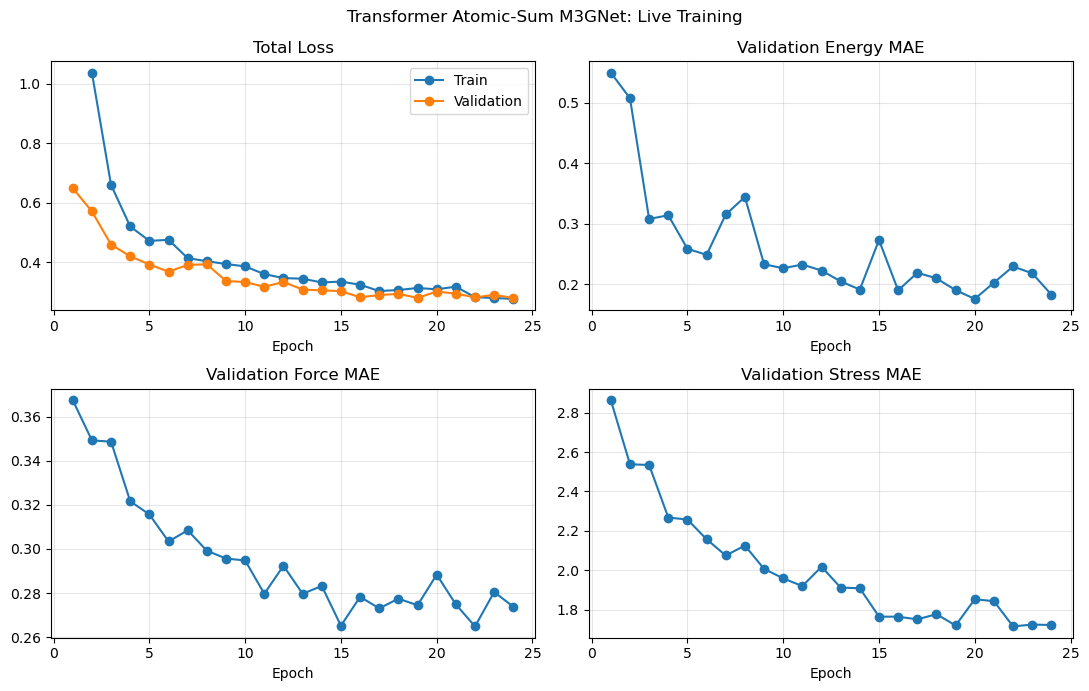

Epoch 24: train_loss=0.2759, val_loss=0.2791

Monitored metric val_Total_Loss did not improve in the last 5 records. Best score: 0.279. Signaling Trainer to stop.


training finished
epochs completed: 25
training minutes: 70.40144016833331
best val loss: 0.27913546562194824
best checkpoint: logs\Transformer-AtomicSum-grouped5000-seed2030\version_0\checkpoints\best-epoch=23-step=24120.ckpt
early stopping reason: 23


In [7]:
import time

from torch.nn.attention import (
    SDPBackend,
    sdpa_kernel,
)

training_start = time.perf_counter()

# MATH attention后端支持力损失训练所需的二阶梯度
with sdpa_kernel(SDPBackend.MATH):
    trainer_5k.fit(
        model=transformer_5k_lit,
        train_dataloaders=train_loader_5k,
        val_dataloaders=val_loader_5k,
    )

transformer_5k_minutes = (
    time.perf_counter() - training_start
) / 60

best_val_loss = (
    float(checkpoint_5k.best_model_score.detach().cpu())
    if checkpoint_5k.best_model_score is not None
    else None
)

print("training finished")
print("epochs completed:", trainer_5k.current_epoch + 1)
print("training minutes:", transformer_5k_minutes)
print("best val loss:", best_val_loss)
print("best checkpoint:", checkpoint_5k.best_model_path)
print("early stopping reason:", early_stop_5k.stopped_epoch)

测试最佳 checkpoint：

加载第24轮最佳参数

→ 在完全未参与训练和调参的486个测试结构上预测

→ 输出Energy / Force / Stress MAE和RMSE


In [8]:
from torch.nn.attention import (
    SDPBackend,
    sdpa_kernel,
)

with sdpa_kernel(SDPBackend.MATH):
    transformer_5k_test_result = trainer_5k.test(
        model=transformer_5k_lit,
        dataloaders=test_loader_5k,
        ckpt_path=checkpoint_5k.best_model_path,
    )[0]

print("best checkpoint:")
print(checkpoint_5k.best_model_path)

print("\nTransformer 5000 test result:")

for key, value in transformer_5k_test_result.items():
    print(f"{key}: {value}")

Restoring states from the checkpoint path at logs\Transformer-AtomicSum-grouped5000-seed2030\version_0\checkpoints\best-epoch=23-step=24120.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at logs\Transformer-AtomicSum-grouped5000-seed2030\version_0\checkpoints\best-epoch=23-step=24120.ckpt


Output()

d:\anaconda\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      test_Charge_MAE      │            0.0            │
│     test_Charge_RMSE      │            0.0            │
│      test_Energy_MAE      │    0.18424828350543976    │
│     test_Energy_RMSE      │    0.22204650938510895    │
│      test_Force_MAE       │     0.285269558429718     │
│      test_Force_RMSE      │    0.48394790291786194    │
│      test_Magmom_MAE      │            0.0            │
│     test_Magmom_RMSE      │            0.0            │
│      test_Stress_MAE      │    1.5402250289916992     │
│     test_Stress_RMSE      │     2.500600576400757     │
│      test_Total_Loss      │    0.2611696124076843     │
└───────────────────────────┴───────────────────────────┘

best checkpoint:
logs\Transformer-AtomicSum-grouped5000-seed2030\version_0\checkpoints\best-epoch=23-step=24120.ckpt

Transformer 5000 test result:
test_Total_Loss: 0.2611696124076843
test_Energy_MAE: 0.18424828350543976
test_Force_MAE: 0.285269558429718
test_Stress_MAE: 1.5402250289916992
test_Magmom_MAE: 0.0
test_Charge_MAE: 0.0
test_Energy_RMSE: 0.22204650938510895
test_Force_RMSE: 0.48394790291786194
test_Stress_RMSE: 2.500600576400757
test_Magmom_RMSE: 0.0
test_Charge_RMSE: 0.0


接下来可以启动原始M3GNET训练

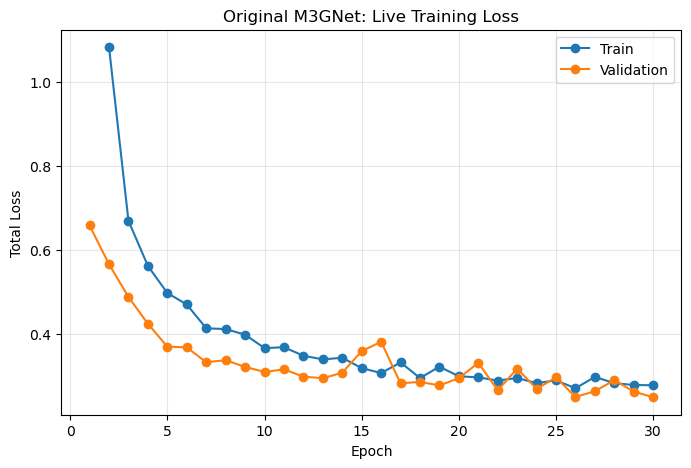

Epoch 30: train=0.2774, validation=0.2489

`Trainer.fit` stopped: `max_epochs=30` reached.


training finished
validation epochs completed: 30
training minutes: 91.0522685533333
best val loss: 0.24890856444835663
best checkpoint: logs\Original-M3GNet-grouped5000-seed2030\version_0\checkpoints\best-epoch=29-step=30150.ckpt
early stopping epoch: 0


In [9]:
class NamedLiveLossPlot(Callback):
    """实时显示训练与验证总损失。"""

    def __init__(self, title):
        super().__init__()
        self.title = title
        self.epochs = []
        self.train_loss = []
        self.val_loss = []

    @staticmethod
    def value(metrics, name):
        metric = metrics.get(name)

        if metric is None:
            return float("nan")

        return float(metric.detach().cpu())

    def on_validation_epoch_end(self, trainer, pl_module):
        if trainer.sanity_checking:
            return

        metrics = trainer.callback_metrics

        self.epochs.append(trainer.current_epoch + 1)
        self.train_loss.append(
            self.value(metrics, "train_Total_Loss")
        )
        self.val_loss.append(
            self.value(metrics, "val_Total_Loss")
        )

        clear_output(wait=True)

        plt.figure(figsize=(8, 5))
        plt.plot(
            self.epochs,
            self.train_loss,
            marker="o",
            label="Train",
        )
        plt.plot(
            self.epochs,
            self.val_loss,
            marker="o",
            label="Validation",
        )
        plt.xlabel("Epoch")
        plt.ylabel("Total Loss")
        plt.title(self.title)
        plt.grid(alpha=0.3)
        plt.legend()
        plt.show()

        print(
            f"Epoch {trainer.current_epoch + 1}: "
            f"train={self.train_loss[-1]:.4f}, "
            f"validation={self.val_loss[-1]:.4f}"
        )


# 与Transformer版本使用相同随机种子
L.seed_everything(42, workers=True)

baseline_5k_model = M3GNet(
    element_types=DEFAULT_ELEMENTS,
    is_intensive=False,
)

xavier_init(baseline_5k_model)

baseline_5k_lit = PotentialLightningModule(
    model=baseline_5k_model,
    energy_weight=1.0,
    force_weight=1.0,
    stress_weight=0.1,
    loss="huber_loss",
    lr=1e-3,
)

baseline_live_plot = NamedLiveLossPlot(
    "Original M3GNet: Live Training Loss"
)

baseline_early_stop = EarlyStopping(
    monitor="val_Total_Loss",
    mode="min",
    min_delta=0.002,
    patience=5,
    verbose=True,
)

baseline_checkpoint = ModelCheckpoint(
    monitor="val_Total_Loss",
    mode="min",
    save_top_k=1,
    filename="best-{epoch:02d}-{step}",
)

baseline_logger = CSVLogger(
    save_dir="logs",
    name="Original-M3GNet-grouped5000-seed2030",
)

baseline_trainer = L.Trainer(
    max_epochs=30,
    accelerator="gpu",
    devices=1,
    precision="32-true",
    inference_mode=False,
    logger=baseline_logger,
    callbacks=[
        baseline_live_plot,
        baseline_early_stop,
        baseline_checkpoint,
        LearningRateMonitor(logging_interval="epoch"),
    ],
    num_sanity_val_steps=0,
    log_every_n_steps=50,
    gradient_clip_val=2.0,
)

print("final layer:", type(baseline_5k_model.final_layer).__name__)
print("is_intensive:", baseline_5k_model.is_intensive)
print(
    "parameters:",
    sum(
        p.numel()
        for p in baseline_5k_model.parameters()
        if p.requires_grad
    ),
)

baseline_start = time.perf_counter()

# 原始M3GNet没有Transformer，不需要sdpa_kernel
baseline_trainer.fit(
    model=baseline_5k_lit,
    train_dataloaders=train_loader_5k,
    val_dataloaders=val_loader_5k,
)

baseline_5k_minutes = (
    time.perf_counter() - baseline_start
) / 60

baseline_best_val_loss = (
    float(
        baseline_checkpoint.best_model_score
        .detach()
        .cpu()
    )
    if baseline_checkpoint.best_model_score is not None
    else None
)

print("training finished")
print(
    "validation epochs completed:",
    len(baseline_live_plot.epochs),
)
print("training minutes:", baseline_5k_minutes)
print("best val loss:", baseline_best_val_loss)
print(
    "best checkpoint:",
    baseline_checkpoint.best_model_path,
)
print(
    "early stopping epoch:",
    baseline_early_stop.stopped_epoch,
)

既检查最后一层，也用最佳 checkpoint 测试：

In [10]:
# 确认原始 M3GNet 使用的最后一层
print(
    "final layer:",
    type(baseline_5k_model.final_layer).__name__,
)
print(
    "is_intensive:",
    baseline_5k_model.is_intensive,
)

assert (
    type(baseline_5k_model.final_layer).__name__
    == "WeightedReadOut"
)

# 使用验证集表现最好的 checkpoint 测试
baseline_5k_test_result = baseline_trainer.test(
    model=baseline_5k_lit,
    dataloaders=test_loader_5k,
    ckpt_path=baseline_checkpoint.best_model_path,
)[0]

print("\nbest checkpoint:")
print(baseline_checkpoint.best_model_path)

print("\nOriginal M3GNet 5000 test result:")
for key, value in baseline_5k_test_result.items():
    print(f"{key}: {value}")

Restoring states from the checkpoint path at logs\Original-M3GNet-grouped5000-seed2030\version_0\checkpoints\best-epoch=29-step=30150.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at logs\Original-M3GNet-grouped5000-seed2030\version_0\checkpoints\best-epoch=29-step=30150.ckpt


Output()

final layer: WeightedReadOut
is_intensive: False


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      test_Charge_MAE      │            0.0            │
│     test_Charge_RMSE      │            0.0            │
│      test_Energy_MAE      │    0.1602655053138733     │
│     test_Energy_RMSE      │    0.19609278440475464    │
│      test_Force_MAE       │    0.28426432609558105    │
│      test_Force_RMSE      │    0.47401225566864014    │
│      test_Magmom_MAE      │            0.0            │
│     test_Magmom_RMSE      │            0.0            │
│      test_Stress_MAE      │     1.567802906036377     │
│     test_Stress_RMSE      │    2.6053738594055176     │
│      test_Total_Loss      │    0.2547815144062042     │
└───────────────────────────┴───────────────────────────┘


best checkpoint:
logs\Original-M3GNet-grouped5000-seed2030\version_0\checkpoints\best-epoch=29-step=30150.ckpt

Original M3GNet 5000 test result:
test_Total_Loss: 0.2547815144062042
test_Energy_MAE: 0.1602655053138733
test_Force_MAE: 0.28426432609558105
test_Stress_MAE: 1.567802906036377
test_Magmom_MAE: 0.0
test_Charge_MAE: 0.0
test_Energy_RMSE: 0.19609278440475464
test_Force_RMSE: 0.47401225566864014
test_Stress_RMSE: 2.6053738594055176
test_Magmom_RMSE: 0.0
test_Charge_RMSE: 0.0


现在 5000 条的两组对照已经完成。接下来新抽一批 1000 条，使用新种子 2031，然后普通随机划分 800/100/100，完全不看 original_mp_id。

In [11]:
import json
import random
import ijson
import numpy as np

from pathlib import Path
from functools import partial
from huggingface_hub import hf_hub_download
from ase.stress import voigt_6_to_full_3x3_stress

from matgl.config import DEFAULT_ELEMENTS
from matgl.graph.data import (
    MGLDataLoader,
    collate_fn_pes,
    split_dataset,
)
from matgl.utils.training import MGLDatasetLoader


TARGET_N_1K = 1_000
SAMPLE_SEED_1K = 2031

# 获取完整MatPES文件；已经下载过时直接读取本地缓存
raw_path_1k = Path(
    hf_hub_download(
        repo_id="materialyze/matpes",
        filename="MatPES-PBE-2025.2.json",
        repo_type="dataset",
    )
)

random_1k_new_path = (
    repo_path
    / f"MatPES-PBE-2025.2-random-{TARGET_N_1K}"
      f"-seed-{SAMPLE_SEED_1K}.json"
)

tmp_1k_path = random_1k_new_path.with_suffix(".json.tmp")

# 从完整数据集中等概率随机抽取1000条
if not random_1k_new_path.exists():
    rng = random.Random(SAMPLE_SEED_1K)
    reservoir = []
    seen = 0

    with raw_path_1k.open("rb") as f:
        for seen, item in enumerate(
            ijson.items(f, "item", use_float=True),
            start=1,
        ):
            item_json = json.dumps(
                item,
                ensure_ascii=False,
                separators=(",", ":"),
            )

            if seen <= TARGET_N_1K:
                reservoir.append(item_json)
            else:
                j = rng.randrange(seen)

                if j < TARGET_N_1K:
                    reservoir[j] = item_json

            if seen % 100_000 == 0:
                print(f"已经扫描：{seen:,} 条")

    rng.shuffle(reservoir)

    with tmp_1k_path.open("w", encoding="utf-8") as out:
        out.write("[\n")
        out.write(",\n".join(reservoir))
        out.write("\n]\n")

    tmp_1k_path.replace(random_1k_new_path)

# JSON转换为PyG图数据集
dataset_1k_plain = MGLDatasetLoader.from_json(
    random_1k_new_path,
    cutoff=5.0,
    element_types=DEFAULT_ELEMENTS,
    save_cache=False,
    root="tmp_random_1000_seed2031_plain_split",
    stress_unit="kbar",
)

# 将Voigt六分量应力转换成3×3矩阵
dataset_1k_plain.labels["stresses"] = [
    (
        voigt_6_to_full_3x3_stress(
            np.asarray(stress, dtype=float)
        ).tolist()
        if np.asarray(stress).shape == (6,)
        else np.asarray(stress, dtype=float).tolist()
    )
    for stress in dataset_1k_plain.labels["stresses"]
]

# 普通样本级随机划分，不使用original_mp_id
train_1k_plain, val_1k_plain, test_1k_plain = split_dataset(
    dataset_1k_plain,
    frac_list=[0.8, 0.1, 0.1],
    shuffle=True,
    random_state=42,
)

collate_1k_plain = partial(
    collate_fn_pes,
    include_stress=True,
)

train_loader_1k_plain, val_loader_1k_plain, test_loader_1k_plain = (
    MGLDataLoader(
        train_data=train_1k_plain,
        val_data=val_1k_plain,
        test_data=test_1k_plain,
        collate_fn=collate_1k_plain,
        batch_size=4,
        num_workers=0,
        pin_memory=True,
    )
)

print("random file:", random_1k_new_path)
print("dataset:", len(dataset_1k_plain))
print(
    "split:",
    len(train_1k_plain),
    len(val_1k_plain),
    len(test_1k_plain),
)
print(
    "batches:",
    len(train_loader_1k_plain),
    len(val_loader_1k_plain),
    len(test_loader_1k_plain),
)
print(
    "stress shape:",
    np.asarray(dataset_1k_plain.labels["stresses"][0]).shape,
)

已经扫描：100,000 条
已经扫描：200,000 条
已经扫描：300,000 条
已经扫描：400,000 条


Processing...
100%|██████████| 1000/1000 [00:00<00:00, 3447.77it/s]

random file: D:\MEGNET_GITHUB\matgl\MatPES-PBE-2025.2-random-1000-seed-2031.json
dataset: 1000
split: 800 100 100
batches: 200 25 25
stress shape: (3, 3)



Done!


下一格完成 Transformer 版本的 10 轮训练，并自动用最佳 checkpoint 测试：

In [13]:
import time
import lightning as L

from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger
from torch.nn.attention import SDPBackend, sdpa_kernel

from matgl.utils.training import (
    PotentialLightningModule,
    xavier_init,
)


# 固定随机初始化，便于复现
L.seed_everything(42, workers=True)
torch.set_float32_matmul_precision("high")

# Transformer + atomic-energy sum 模型
transformer_1k_model = M3GNet(
    element_types=DEFAULT_ELEMENTS,
    is_intensive=False,
    readout_type="transformer",
    transformer_nhead=4,
    transformer_num_layers=1,
    transformer_dim_ff=128,
    transformer_dropout=0.0,
)

xavier_init(transformer_1k_model)

transformer_1k_lit = PotentialLightningModule(
    model=transformer_1k_model,
    energy_weight=1.0,
    force_weight=1.0,
    stress_weight=0.1,
    loss="huber_loss",
    lr=1e-3,
)

# 保存验证损失最低的模型
checkpoint_1k = ModelCheckpoint(
    monitor="val_Total_Loss",
    mode="min",
    save_top_k=1,
    filename="best-{epoch:02d}-{step}",
)

logger_1k = CSVLogger(
    save_dir="logs",
    name="Transformer-AtomicSum-random1000-seed2031-ep10",
)

trainer_1k = L.Trainer(
    max_epochs=10,
    accelerator="gpu",
    devices=1,
    precision="32-true",
    inference_mode=False,
    logger=logger_1k,
    callbacks=[checkpoint_1k],
    num_sanity_val_steps=0,
    log_every_n_steps=20,
    gradient_clip_val=2.0,
)

print("final layer:", type(transformer_1k_model.final_layer).__name__)
print("is_intensive:", transformer_1k_model.is_intensive)
print(
    "parameters:",
    sum(
        p.numel()
        for p in transformer_1k_model.parameters()
        if p.requires_grad
    ),
)

start = time.perf_counter()

# MATH attention支持力损失需要的二阶梯度
with sdpa_kernel(SDPBackend.MATH):
    trainer_1k.fit(
        model=transformer_1k_lit,
        train_dataloaders=train_loader_1k_plain,
        val_dataloaders=val_loader_1k_plain,
    )

    transformer_1k_test = trainer_1k.test(
        model=transformer_1k_lit,
        dataloaders=test_loader_1k_plain,
        ckpt_path=checkpoint_1k.best_model_path,
    )[0]

minutes = (time.perf_counter() - start)

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


final layer: TransformerAtomicReadOut
is_intensive: False
parameters: 321629


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ mae   │ MeanAbsoluteError │      0 │ train │     0 │
│ 1 │ rmse  │ MeanSquaredError  │      0 │ train │     0 │
│ 2 │ model │ Potential         │  321 K │ train │     0 │
└───┴───────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 321 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 321 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 187                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=10` reached.


Restoring states from the checkpoint path at logs\Transformer-AtomicSum-random1000-seed2031-ep10\version_1\checkpoints\best-epoch=08-step=1800.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at logs\Transformer-AtomicSum-random1000-seed2031-ep10\version_1\checkpoints\best-epoch=08-step=1800.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      test_Charge_MAE      │            0.0            │
│     test_Charge_RMSE      │            0.0            │
│      test_Energy_MAE      │    0.43792209029197693    │
│     test_Energy_RMSE      │    0.5081285238265991     │
│      test_Force_MAE       │    0.3229978680610657     │
│      test_Force_RMSE      │    0.4840754568576813     │
│      test_Magmom_MAE      │            0.0            │
│     test_Magmom_RMSE      │            0.0            │
│      test_Stress_MAE      │     2.299083948135376     │
│     test_Stress_RMSE      │     3.626182794570923     │
│      test_Total_Loss      │    0.4703819155693054     │
└───────────────────────────┴───────────────────────────┘